In [221]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import date, timedelta
import seaborn as sns
sns.set()
plt.style.use('fivethirtyeight')

#calculate date range
today = date.today()
end_date = today.strftime("%Y-%m-%d")
d2= date.today() - timedelta(days=5000)
start_date = d2.strftime("%Y-%m-%d")
print('today : ',today)
print('start_date : ',start_date)
print('end_date : ',end_date)

#data load
df = yf.download('AAPL', start=start_date, end=end_date, progress=False)
df['Date'] = df.index
df = df[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]
df.reset_index(drop=True, inplace=True)

today :  2023-09-15
start_date :  2010-01-06
end_date :  2023-09-15


In [222]:
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
246,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
247,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
248,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200
249,2023-09-13,176.509995,177.300003,173.979996,174.210007,174.210007,84267900
250,2023-09-14,174.000000,176.100006,173.580002,175.740005,175.740005,60832500


In [223]:
# Calculate the current date
current_date = pd.Timestamp(today)
print('current_date : ',current_date)

current_date :  2023-09-15 00:00:00


In [224]:
# Filter data for the last 10 days from the current date
last_10_days_data = df[(df['Date'] > (current_date - pd.DateOffset(days=10))) & (df['Date'] <= current_date)]
last_10_days_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
3439,2023-09-06,188.399994,188.850006,181.470001,182.910004,182.910004,81755800
3440,2023-09-07,175.179993,178.210007,173.539993,177.559998,177.559998,112488800
3441,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
3442,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
3443,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200


In [225]:
# Split the data into features (X) and target (y) for the last 10 days
X_historical_10_days = last_10_days_data[['Open', 'High', 'Low', 'Volume']]
y_historical_10_days = last_10_days_data['Close']

               Date      Open      High       Low     Close  Adj Close  \
Date       1.000000  0.859450  0.854866  0.862730  0.857561   0.861595   
Open       0.859450  1.000000  0.996923  0.997300  0.992969   0.993054   
High       0.854866  0.996923  1.000000  0.997159  0.997170   0.997112   
Low        0.862730  0.997300  0.997159  1.000000  0.997297   0.997366   
Close      0.857561  0.992969  0.997170  0.997297  1.000000   0.999962   
Adj Close  0.861595  0.993054  0.997112  0.997366  0.999962   1.000000   
Volume    -0.526790 -0.440095 -0.414693 -0.460811 -0.437123  -0.439577   

             Volume  
Date      -0.526790  
Open      -0.440095  
High      -0.414693  
Low       -0.460811  
Close     -0.437123  
Adj Close -0.439577  
Volume     1.000000  


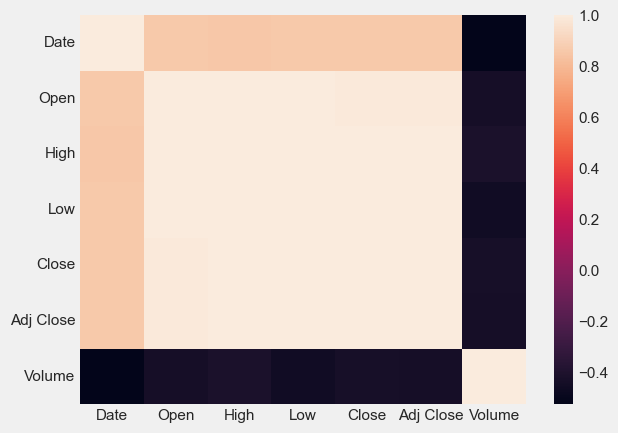

In [226]:
print(data.corr())
sns.heatmap(data.corr())
plt.show()

In [229]:
# Split the data into features (X) and target (y) for the entire dataset
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# Split the data into training and testing sets for the entire dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree Regressor
model = DecisionTreeRegressor(random_state=42)
# Train the model on the training data for the entire dataset
model.fit(X_train, y_train)

# Calculate the next 5 business days after the current date
next_5_business_days = pd.bdate_range(start=current_date + pd.DateOffset(days=1), periods=5)

# Make predictions for the next 5 business days
future_data = pd.DataFrame({
    'Date': next_5_business_days,
    'Open': np.nan,
    'High': np.nan,
    'Low': np.nan,
    'Volume': np.nan
})
predicted_prices = model.predict(future_data[['Open', 'High', 'Low', 'Volume']])
print("predicted_prices : ", predicted_prices)
data = pd.DataFrame(data={"Predicted Rate": ypred})
print(data.head())

predicted_prices :  [12.43428612 12.43428612 12.43428612 12.43428612 12.43428612]
   Predicted Rate
0      148.910004
1      148.910004
2      148.910004
3      148.910004
4      148.910004


23/09/15 10:14:54 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 397355 ms exceeds timeout 120000 ms
23/09/15 10:14:54 WARN SparkContext: Killing executors is not supported by current scheduler.


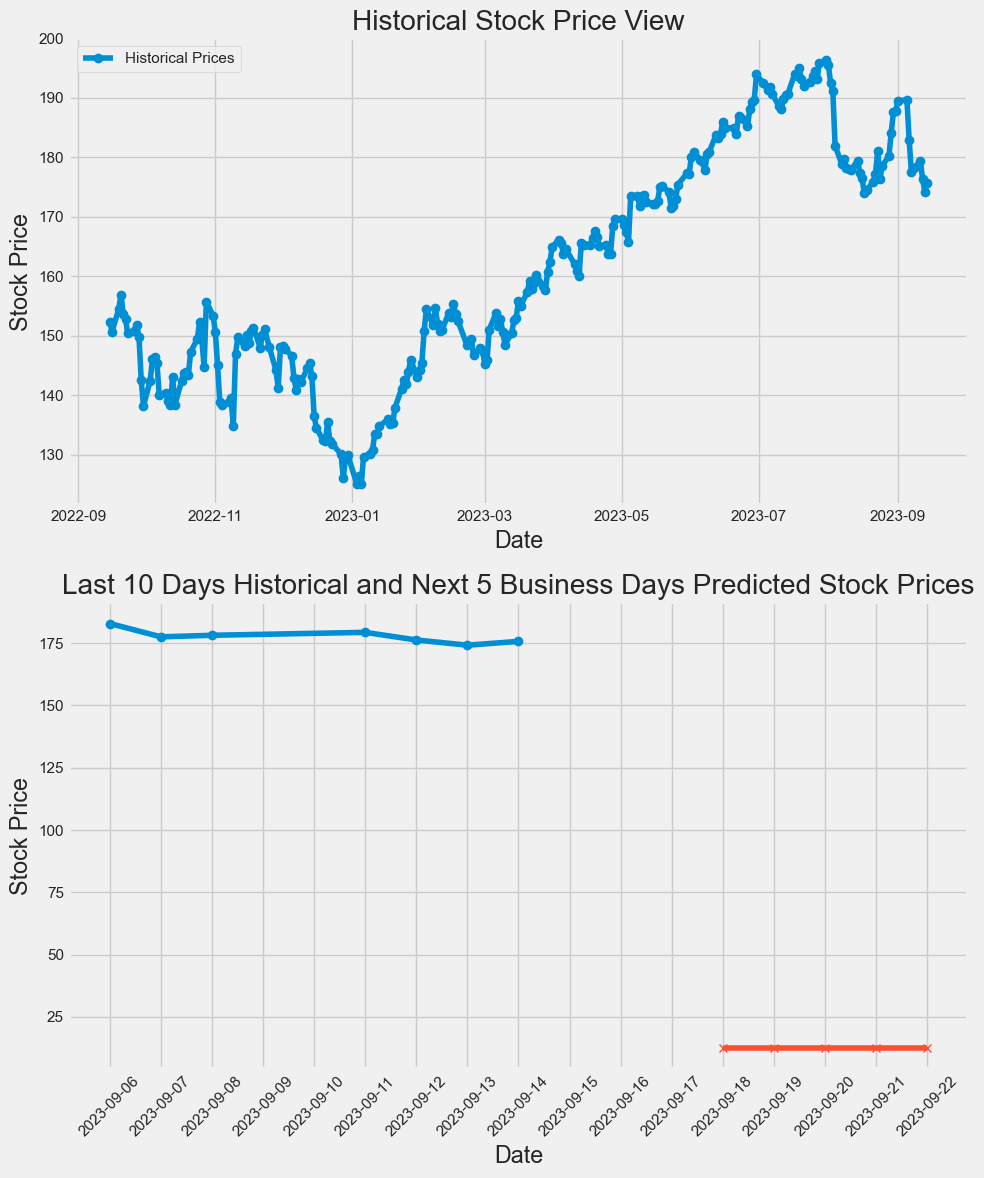

In [228]:
# Create subplots with two charts
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Plot all historical data in the first graph
axes[0].plot(data['Date'], data['Close'], label='Historical Prices', marker='o')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Stock Price')
axes[0].set_title('Historical Stock Price View')
axes[0].legend()

# Plot the last 10 days of historical prices and the next 5 business days of predicted prices in the second graph
axes[1].plot(last_10_days_data['Date'], last_10_days_data['Close'], label='Last 10 Days Historical Prices', marker='o')
axes[1].plot(next_5_business_days, predicted_prices, label='Predicted Prices', marker='x')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Stock Price')
axes[1].set_title('Last 10 Days Historical and Next 5 Business Days Predicted Stock Prices')
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Set daily date locator
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))  # Format date labels

# Rotate the labels by 45 degrees
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()